# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [4]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 


In [5]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


In [6]:

from pandas.api.types import is_numeric_dtype

# Methos to show the details of null cols and the % of null values in each cols.
def show_null_counts_features(df):
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)  
    feature_types = df.dtypes.apply(
        lambda x: 'Numeric' if is_numeric_dtype(x) else 'Categorical'
    )
    
    print(f'The dataset contains {len(df)} samples.\n')
    
    missing_cols = count_nulls[count_nulls > 0].index  
    if len(missing_cols) == 0:
        print("There are no null values in the dataset!")
        return None
    
    missing_data = pd.DataFrame({
        '# Null Values': count_nulls[missing_cols], 
        'Null %': df_nulls[missing_cols],
        'Type': feature_types[missing_cols]
    }).sort_values(by='Null %', ascending=False)
    
    # missing_data.index.name = 'Feature'
    display(missing_data)    

## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

> Replace this text with your answer.


**1.2:**  How will your solution be used?

> Replace this text with your answer.

**1.3:**  How should success (or failure) be measured?

> Replace this text with your answer.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [7]:
print("Feature names from the zillow dataset")
print(df.columns.tolist())

# Categorical features
cat_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
print(f"\nTotal Categorical features : {len(cat_cols)}")
print(cat_cols)

# Numeric features (everything that isn’t object / category)
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print(f"\nTotal Numerical features : {len(num_cols)}")
print(num_cols)

print("\nCount of null values / percentage in each feature")
show_null_counts_features(df)

print("Unique value count for each feature")
df.nunique().sort_values()

Feature names from the zillow dataset
['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid', 'buildingqualitytypeid', 'calculatedbathnbr', 'decktypeid', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fips', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'unitcnt', 'yardbuildingsqft17', 'yardbuildingsqft26', 'yearbuilt', 'numberofstories', 'fireplaceflag', 

,# Null Values,Null %,Type
buildingclasstypeid,77598,99.98,Numeric
finishedsquarefeet13,77571,99.95,Numeric
basementsqft,77563,99.94,Numeric
storytypeid,77563,99.94,Numeric
yardbuildingsqft26,77543,99.91,Numeric
fireplaceflag,77441,99.78,Categorical
architecturalstyletypeid,77406,99.73,Numeric
typeconstructiontypeid,77390,99.71,Numeric
finishedsquarefeet6,77227,99.50,Numeric
pooltypeid10,77148,99.40,Numeric


Unique value count for each feature


decktypeid                          1
pooltypeid7                         1
pooltypeid2                         1
pooltypeid10                        1
poolcnt                             1
hashottuborspa                      1
taxdelinquencyflag                  1
storytypeid                         1
fireplaceflag                       1
assessmentyear                      1
buildingclasstypeid                 2
regionidcounty                      3
fips                                3
typeconstructiontypeid              4
numberofstories                     4
threequarterbathnbr                 4
architecturalstyletypeid            5
fireplacecnt                        5
airconditioningtypeid               5
unitcnt                             8
heatingorsystemtypeid              10
buildingqualitytypeid              12
propertylandusetypeid              13
taxdelinquencyyear                 13
fullbathcnt                        13
finishedsquarefeet13               13
garagecarcnt

#### **2.A Discussion:** 

Answer the following questions. You may wish to examine Appendix 3 before starting. 

**2.A.1:**  Which features are categorical?

> Replace this text with your answer.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

> Replace this text with your answer.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

> Replace this text with your answer.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features): 
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

#### **2.B Discussion:** 

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).

> Replace this text with your answer. Organize your discussion by feature, then conclude with your thoughts about possible future preprocessing.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

> Replace this text with your answer.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.

> Replace this text with your answer.

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.

> Replace this text with your answer.

### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage"). 

No discussion necessary. 

### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.

> Replace this text with your answer.

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

> Replace this text with your answer.

## Part 4: Investigate Feature Relationships [6 pts]

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

Using 28 true-numeric features (of 50 numeric-dtype cols).


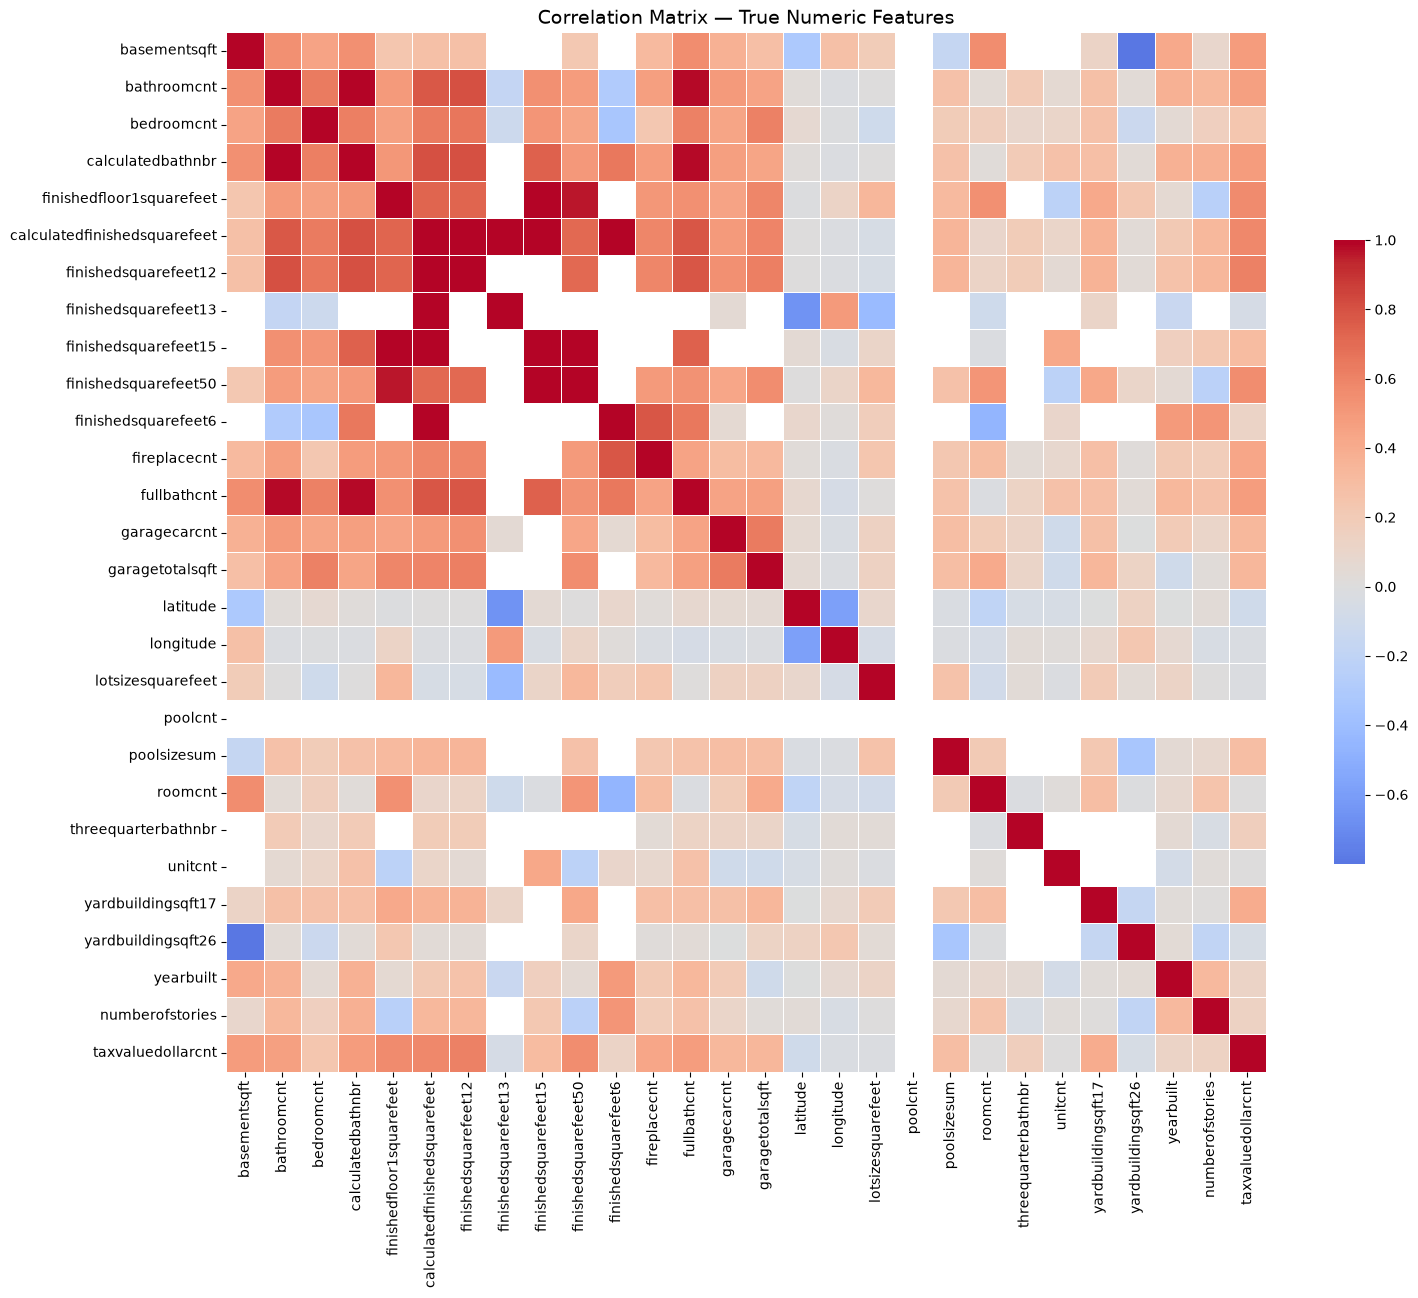

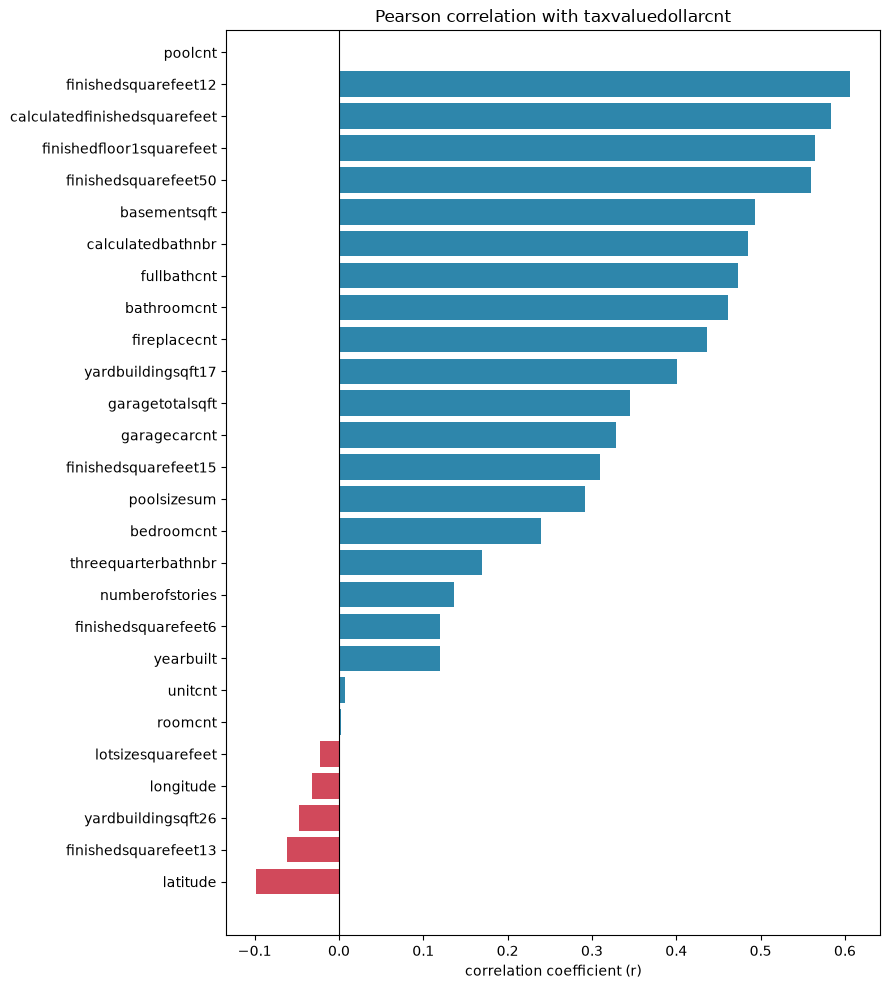


Correlation with target (watch n_pairs — a high r on few rows is unreliable):
                                  r  abs_r  n_pairs  null_%
finishedsquarefeet12          0.606  0.606    73922     4.8
calculatedfinishedsquarefeet  0.583  0.583    77377     0.3
finishedfloor1squarefeet      0.565  0.565     6037    92.2
finishedsquarefeet50          0.560  0.560     6037    92.2
basementsqft                  0.494  0.494       50    99.9
calculatedbathnbr             0.485  0.485    76962     0.8
fullbathcnt                   0.473  0.473    76962     0.8
bathroomcnt                   0.461  0.461    77578     0.0
fireplacecnt                  0.436  0.436     8289    89.3
yardbuildingsqft17            0.401  0.401     2393    96.9
garagetotalsqft               0.345  0.345    25519    67.1
garagecarcnt                  0.328  0.328    25519    67.1

Reliable highly-correlated pairs (|r| > 0.8, n >= 1000):
                   feature_1                    feature_2  abs_corr  n_pairs
      

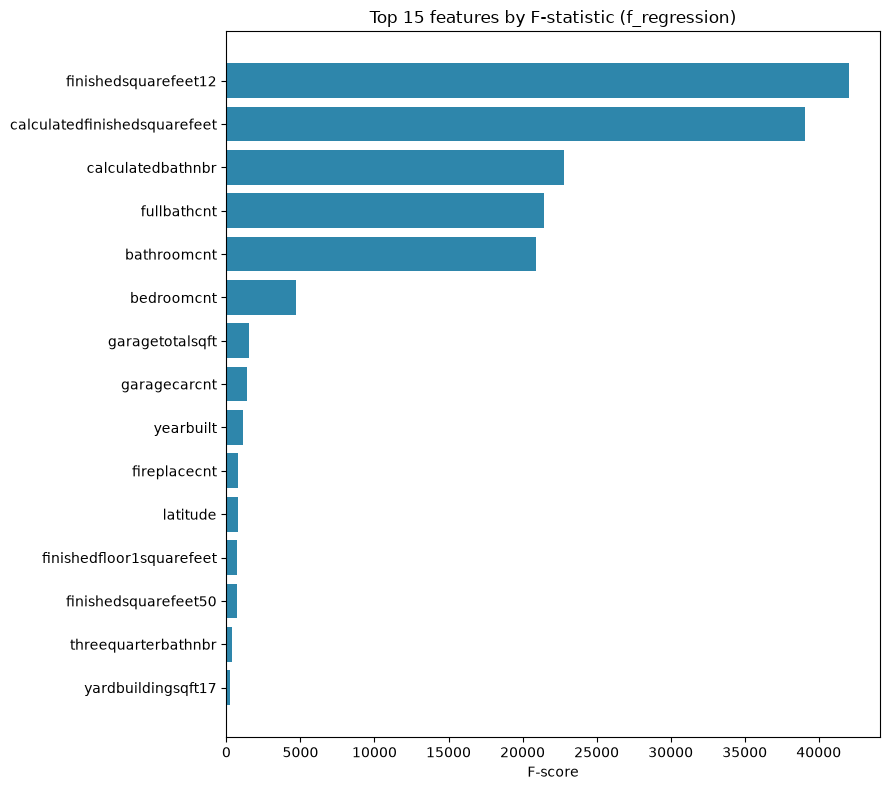


Top 15 features by F-statistic:
                              F_score  p_value
finishedsquarefeet12          42035.8      0.0
calculatedfinishedsquarefeet  39046.6      0.0
calculatedbathnbr             22820.1      0.0
fullbathcnt                   21427.2      0.0
bathroomcnt                   20937.3      0.0
bedroomcnt                     4713.3      0.0
garagetotalsqft                1553.4      0.0
garagecarcnt                   1411.3      0.0
yearbuilt                      1105.2      0.0
fireplacecnt                    768.2      0.0
latitude                        755.8      0.0
finishedfloor1squarefeet        710.5      0.0
finishedsquarefeet50            694.3      0.0
threequarterbathnbr             367.4      0.0
yardbuildingsqft17              249.2      0.0


In [ ]:
# ============================================================
# PART 4.A — Correlation and Feature Importance
# ============================================================
target = 'taxvaluedollarcnt'

# --- 1. Separate TRUE numeric measurements from categorical ID codes ---
# Many columns are numeric in dtype but are really category codes
# a Pearson correlation on arbitrary ID codes is meaningless, so we exclude them.
categorical_coded = [
    'parcelid',
    'airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid',
    'buildingqualitytypeid', 'decktypeid', 'heatingorsystemtypeid',
    'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
    'propertylandusetypeid', 'storytypeid', 'typeconstructiontypeid',
    'fips', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip',
    'rawcensustractandblock', 'censustractandblock',
    'assessmentyear', 'taxdelinquencyyear',
]
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
true_numeric = [c for c in numeric_cols if c not in categorical_coded]
if target not in true_numeric:
    true_numeric.append(target)
print(f"Using {len(true_numeric)} true-numeric features (of {len(numeric_cols)} numeric-dtype cols).")

# --- 2. Correlation matrix + heatmap (pandas drops NaN pairwise) ---
corr = df[true_numeric].corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            linewidths=0.4, cbar_kws={'shrink': 0.6})
plt.title('Correlation Matrix — True Numeric Features', fontsize=14)
plt.tight_layout(); plt.show()

# --- 3. Correlation with the target, ranked (bar chart + diagnostic table) ---
corr_target = corr[target].drop(target).sort_values()
plt.figure(figsize=(9, 10))
colors = ['#d1495b' if v < 0 else '#2e86ab' for v in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(0, color='k', lw=0.8)
plt.title(f'Pearson correlation with {target}')
plt.xlabel('correlation coefficient (r)')
plt.tight_layout(); plt.show()

# r is only trustworthy when computed on many rows track n_pairs and null %
diag = pd.DataFrame({
    'r':       corr_target.round(3),
    'abs_r':   corr_target.abs().round(3),
    'n_pairs': [df[[c, target]].dropna().shape[0] for c in corr_target.index],
    'null_%':  (df[corr_target.index].isnull().mean() * 100).round(1),
}).sort_values('abs_r', ascending=False)
print("\nCorrelation with target (watch n_pairs — a high r on few rows is unreliable):")
print(diag.head(12).to_string())

# --- 4. Highly correlated feature PAIRS, guarded by overlap sample size ---
THRESH, MIN_N = 0.80, 1000   
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.abs().stack().sort_values(ascending=False).reset_index()
pairs.columns = ['feature_1', 'feature_2', 'abs_corr']
pairs['n_pairs'] = [df[[a, b]].dropna().shape[0]
                    for a, b in zip(pairs.feature_1, pairs.feature_2)]
reliable = pairs[(pairs.abs_corr > THRESH) & (pairs.n_pairs >= MIN_N)]
spurious = pairs[(pairs.abs_corr > THRESH) & (pairs.n_pairs <  MIN_N)]
print(f"\nReliable highly-correlated pairs (|r| > {THRESH}, n >= {MIN_N}):")
print(reliable.to_string(index=False))
print(f"\nExcluded as unreliable (too few overlapping rows): {len(spurious)}")
print(spurious.to_string(index=False))

# --- 5. F-statistics (univariate linear strength vs target) ---
# f_regression cannot handle NaN, so drop rows with a missing target and median-fill

feat_cols = [c for c in true_numeric if c != target]
tmp = df[feat_cols + [target]].dropna(subset=[target]).copy()
X = tmp[feat_cols].fillna(tmp[feat_cols].median())
y = tmp[target]
F, p = f_regression(X, y)
f_scores = pd.Series(F, index=feat_cols).sort_values(ascending=False)
p_values = pd.Series(p, index=feat_cols)
topN = f_scores.head(15)
plt.figure(figsize=(9, 8))
plt.barh(topN.index[::-1], topN.values[::-1], color='#2e86ab')
plt.title('Top 15 features by F-statistic (f_regression)')
plt.xlabel('F-score'); plt.tight_layout(); plt.show()
print("\nTop 15 features by F-statistic:")
print(pd.DataFrame({'F_score': f_scores.round(1),
                    'p_value': p_values.reindex(f_scores.index).round(4)}).head(15).to_string())

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.

> The strongest predictors of `taxvaluedollarcnt` are the finished-living-area and bathroom features. Restricting to features with enough data to trust, the top two are `finishedsquarefeet12` (r ≈ 0.61, present on ~74k rows) and `calculatedfinishedsquarefeet` (r ≈ 0.58, ~77k rows), followed by the bathroom cluster `calculatedbathnbr`, `fullbathcnt`, and `bathroomcnt` (r ≈ 0.46–0.49, all ~77k rows). Some features show a higher correlation but on almost no data: `basementsqft` (r ≈ 0.49 on only 50 rows, 99.9% missing) and `finishedfloor1squarefeet` / `finishedsquarefeet50` (r ≈ 0.56 on ~6k rows, 92% missing) so we do not treat those as reliable signals.

> The most highly correlated feature pairs (|r| > 0.80, verified on large samples) form two redundant groups: the bathroom counts (`bathroomcnt`, `calculatedbathnbr`, `fullbathcnt`) are nearly identical at r ≈ 0.98-1.00, and the finished-area measures (`calculatedfinishedsquarefeet`, `finishedsquarefeet12`) are effectively duplicates at r ≈ 1.00. Size and bathroom count also cross-correlate around 0.80. We excluded several apparent r = 1.00 pairs computed on as few as 2-42 overlapping rows, because those are artifacts of pairwise deletion on near-empty columns rather than real relationships.

> The correlation matrix and the F-statistics agree on the top predictors, the finished-area and bathroom/bedroom features rank highest under both. They diverge only on the extremely sparse columns: because the F-statistic computation median-imputes across all ~77.5k rows, a 99.9%-missing feature like `basementsqft` becomes almost constant and correctly ranks as unimportant, whereas the raw pairwise correlation gave it a misleadingly high value from a 50-row sample. We therefore trust the F-statistic ranking more for the sparse features and treat the two methods as consistent for the well-populated ones.

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to have the strongest relationships with the target.
- Which pairs of features appeared to be highly correlated.
- Whether any relationships suggest opportunities for future feature engineering or preprocessing in Milestone 2.

> As above, the features with the strongest relationships to the target are the finished-area measures (`finishedsquarefeet12`, `calculatedfinishedsquarefeet`) and the bathroom-count group (`calculatedbathnbr`, `fullbathcnt`, `bathroomcnt`), with `bedroomcnt` moderately related. The reliably highly correlated pairs are the bathroom-count cluster (r ≈ 0.98–1.00) and the finished-area cluster (r ≈ 1.00), plus a size-to-bathroom cross-correlation near 0.80.

> These relationships point to several feature-engineering ideas to test in Milestone 2. First, the redundant clusters argue for collapsing each group to a single representative feature (or applying dimensionality reduction), since duplicates add multicollinearity without new information. Second, the very high missingness in features like `basementsqft`, `finishedsquarefeet13`, `finishedsquarefeet6`, and `yardbuildingsqft26` (all > 99%) suggests they will likely be dropped in Part 3.B, or converted into simple has/doesn't-have binary indicators rather than kept as continuous values. Third, `latitude` and `longitude` show almost no linear correlation with price despite location being economically important, which hints that location should be engineered differently (for example regional binning or distance-based features) rather than used as raw coordinates. We commit to none of these changes now; they are hypotheses for Part 5 and Milestone 2.



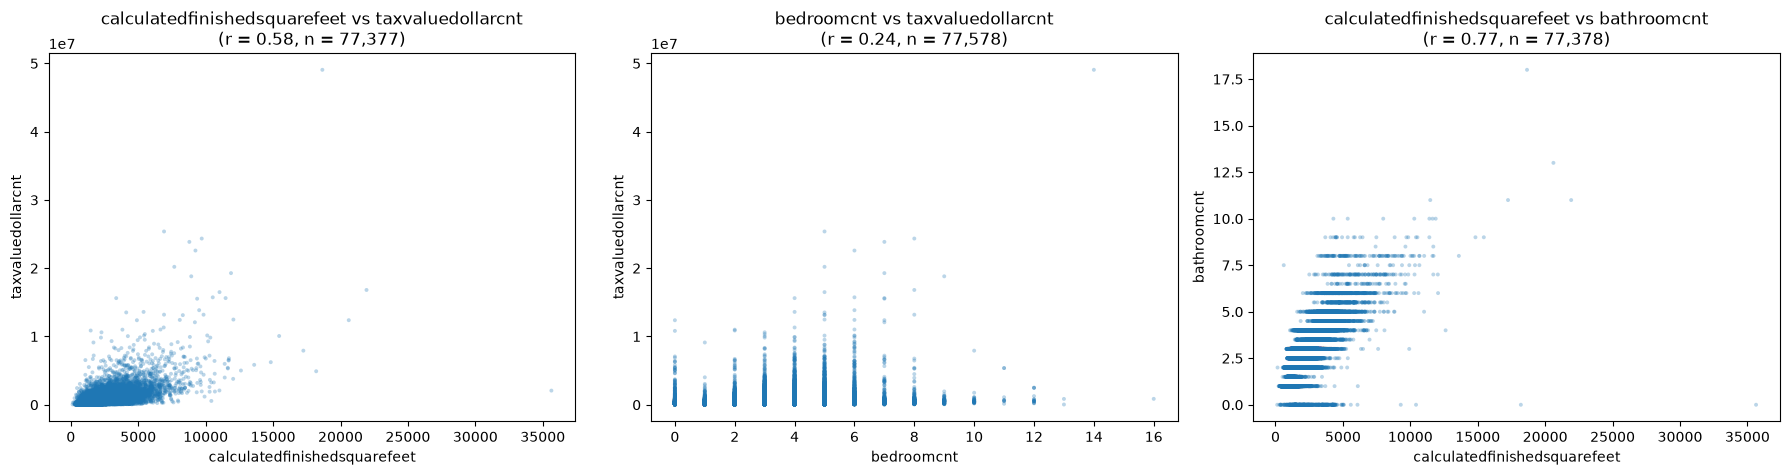

calculatedfinishedsquarefeet vs taxvaluedollarcnt: r = 0.583, n = 77,377
bedroomcnt vs taxvaluedollarcnt: r = 0.239, n = 77,578
calculatedfinishedsquarefeet vs bathroomcnt: r = 0.773, n = 77,378


In [9]:
# ============================================================
# PART 4.B — Three feature relationships (scatter plots)
# ============================================================
# (x_feature, y_feature). Chosen from the 4.A findings: the strongest reliable
# predictor vs target, a count feature vs target, and two correlated predictors.
pairs_to_plot = [
    ('calculatedfinishedsquarefeet', target),          # strong predictor vs target
    ('bedroomcnt',                   target),          # discrete count vs target
    ('calculatedfinishedsquarefeet', 'bathroomcnt'),   # two correlated predictors
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x, yv) in zip(axes, pairs_to_plot):
    sub = df[[x, yv]].dropna()
    ax.scatter(sub[x], sub[yv], s=8, alpha=0.3, edgecolor='none')
    r = sub[x].corr(sub[yv])
    ax.set_xlabel(x); ax.set_ylabel(yv)
    ax.set_title(f'{x} vs {yv}\n(r = {r:.2f}, n = {len(sub):,})')
plt.tight_layout(); plt.show()

for x, yv in pairs_to_plot:
    sub = df[[x, yv]].dropna()
    print(f"{x} vs {yv}: r = {sub[x].corr(sub[yv]):.3f}, n = {len(sub):,}")

#### **4.B Discussion:**

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

> **`calculatedfinishedsquarefeet` vs `taxvaluedollarcnt` (r ≈ 0.58, n ≈ 77k):** a strong, roughly linear positive relationship, larger finished area means higher assessed value. The spread widens as square footage grows (the points fan outward), which is classic heteroskedasticity and suggests a log transform of the target and/or the feature could stabilize the variance in Milestone 2. This is one of the most useful predictors in the dataset.

> **`bedroomcnt` vs `taxvaluedollarcnt` (r ≈ 0.24, n ≈ 77k):** a weak, stepped relationship, as expected for a discrete count. Value rises modestly with bedrooms at the low-to-middle range but flattens and gets noisy at the high end, where extreme bedroom counts likely reflect data-entry issues or unusual multi-unit properties. On its own it's a weak predictor, but it may become useful as an interaction (for example bedrooms relative to square footage) or after outlier handling.

> **`calculatedfinishedsquarefeet` vs `bathroomcnt` (r ≈ 0.77, n ≈ 77k):** a strong positive relationship between two predictors, confirming the redundancy already flagged in the correlation matrix, bigger homes have more bathrooms. This overlap suggests testing whether keeping both features helps or whether one can be dropped, or whether a combined feature (such as bathrooms per square foot) carries the signal more efficiently. All three ideas are hypotheses to evaluate experimentally in Milestone 2, not changes to make now.


## Part 5: Investigate Potential Feature Engineering [6 pts]

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

> Replace this text with your answer.

## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.

> Replace this text with your answer.

#### **5 Discussion:** 

Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.

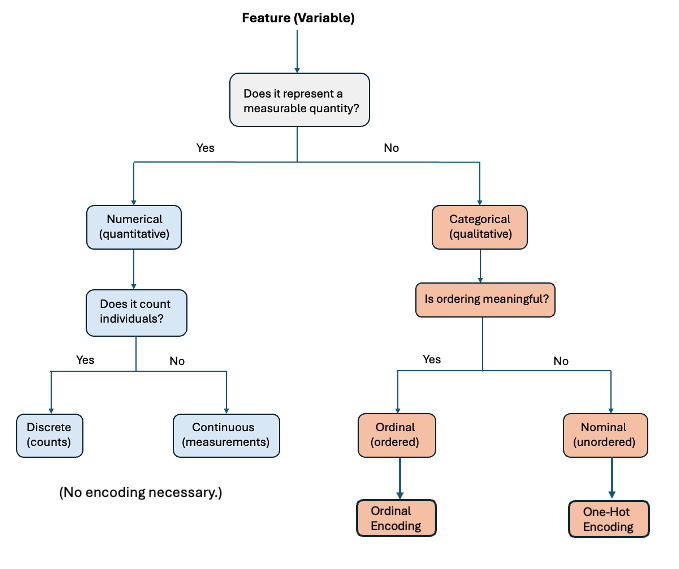